fetching MSFT from 2024-05-30 to 2026-05-30
Ticker: MSFT
last close: $ 450.24
trading days used: 500
annual return (mu): 4.93 %
annual volatility (sigma): 25.09 %
sharpe (approx): 0.2
simulated 1000 paths over 252 trading days.
starting price: $ 450.24
median end price: $ 460.51
5th percentile end price: $ 303.85
95th percentile end price: $ 696.92


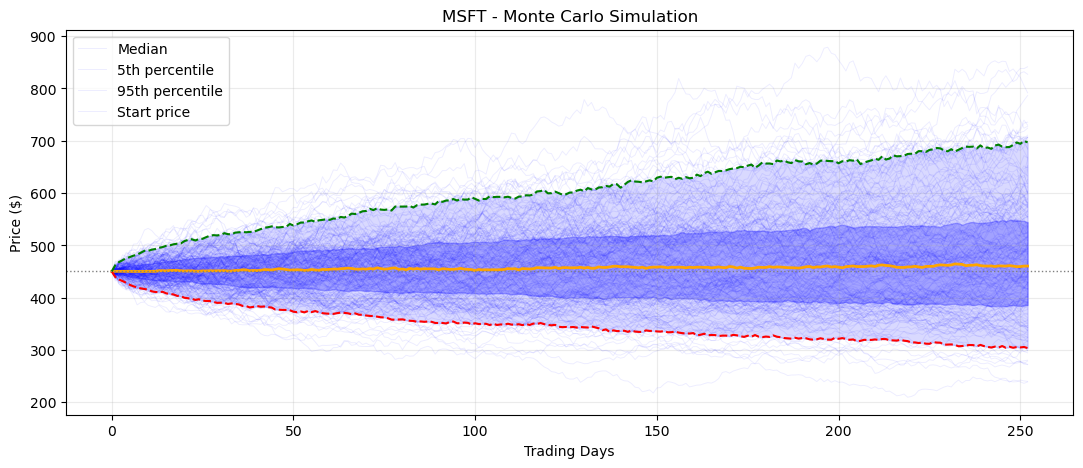

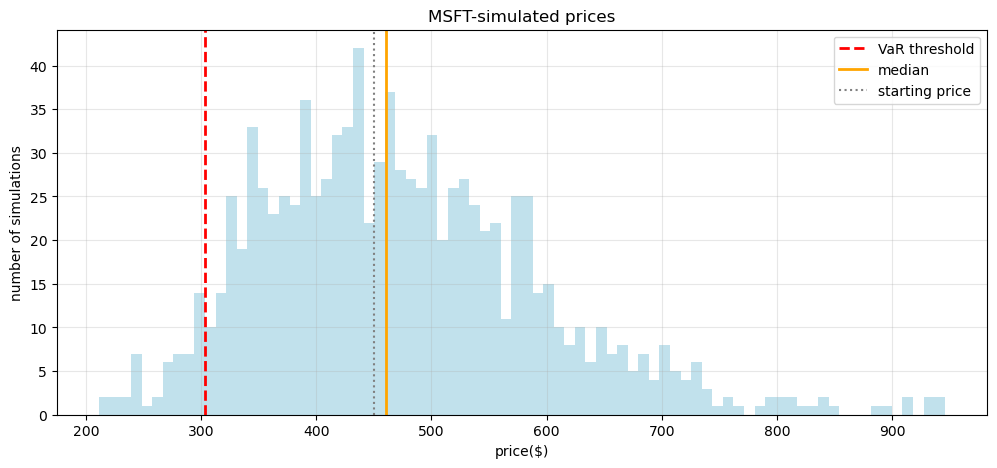


investment summary
investment: $ 1000
shares held: 2.221
horizon: 252 days

VaR(95%): -$ 325.14
CVaR(95%): -$ 394.25
median P&L: $ 22.8
best case(99th): $ 857.37

Sensitivity Table

90.0%  VaR: -$       264  ( 26.40%)  CVaR: -$       341
95.0%  VaR: -$       325  ( 32.51%)  CVaR: -$       394
97.5%  VaR: -$       377  ( 37.69%)  CVaR: -$       440
99.0%  VaR: -$       457  ( 45.73%)  CVaR: -$       485
99.9%  VaR: -$       512  ( 51.18%)  CVaR: -$       530


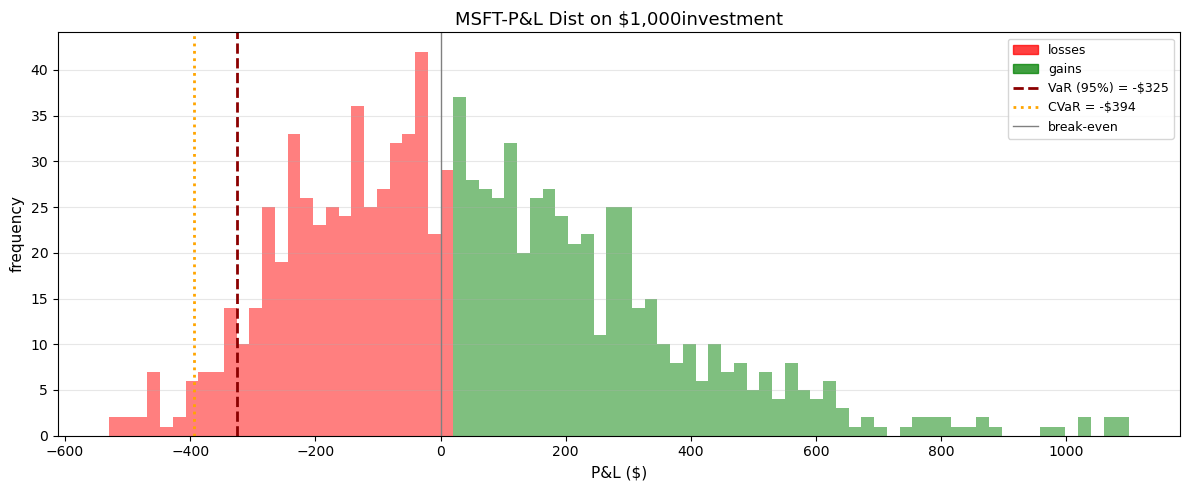

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
#change ticker accordingly
ticker='MSFT'
lookback_years=2 #years of history for mu and sigma
horizon_days=252 #trading days to simulate fowards(252=1 year)
n_simulations=1000
confidence_level=0.95 #for VaR/CVaR
investment=1_000 #dollar amount invested
#give me 2 years of Apple price history ending today
import datetime
end_date=datetime.date.today()
start_date=end_date-datetime.timedelta(days=int(lookback_years*365.25))
print("fetching", ticker, "from", start_date, "to", end_date)
stock=yf.download(ticker, start=start_date,end=end_date,progress=False)
#if data is missing download fails or empty DataFrame
if stock.empty:
    raise ValueError(f'no data found for ticker {ticker}. check symbol')#prevents future crash
prices=stock['Close'].squeeze()#turns into a 1Xn matrix
log_returns=np.log(prices/prices.shift(1)).dropna()
#daily stats
mu_daily=log_returns.mean()
sigma_daily=log_returns.std()
#annual
mu_annual=mu_daily*252
sigma_annual=sigma_daily*np.sqrt(252)
S0=float(prices.iloc[-1])#gives latest closing prices
print("Ticker:", ticker)
print("last close: $", round(S0, 2))
print("trading days used:", len(log_returns))
print("annual return (mu):", round(mu_annual * 100, 2), "%")
print("annual volatility (sigma):", round(sigma_annual * 100, 2), "%")
print("sharpe (approx):", round(mu_annual / sigma_annual, 2))
np.random.seed(42)
dt=1/252#one trading day
z=np.random.standard_normal((horizon_days,n_simulations))
daily_returns=np.exp((mu_daily-0.5*sigma_daily**2)+sigma_daily*z)
price_paths=np.vstack([np.full(n_simulations,S0),S0*np.cumprod(daily_returns,axis=0)])
final_prices=price_paths[-1]
median_price=np.median(final_prices)
percentile_5=np.percentile(final_prices,5)
percentile_95=np.percentile(final_prices,95)
print("simulated", n_simulations, "paths over", horizon_days, "trading days.")
print("starting price: $", round(S0,2))
print("median end price: $", round(median_price,2))
print("5th percentile end price: $", round(percentile_5,2))
print("95th percentile end price: $", round(percentile_95,2))
fig,ax=plt.subplots(figsize=(13,5))
days=np.arange(horizon_days+1)
num_paths=min(200,n_simulations)
for i in range(num_paths):
    ax.plot(days, price_paths[:, i], alpha=0.07, linewidth=0.7, color='blue')
low_5 = np.percentile(price_paths, 5, axis=1)
low_25 = np.percentile(price_paths, 25, axis=1)
median = np.percentile(price_paths, 50, axis=1)
high_75 = np.percentile(price_paths, 75, axis=1)
high_95 = np.percentile(price_paths, 95, axis=1)
ax.fill_between(days, low_5, high_95, alpha=0.15, color='blue')
ax.fill_between(days, low_25, high_75, alpha=0.25, color='blue')
ax.plot(days, median, color='orange', linewidth=2)
ax.plot(days, low_5, color='red', linewidth=1.5, linestyle='--')
ax.plot(days, high_95, color='green', linewidth=1.5, linestyle='--')
ax.axhline(S0, color='gray', linewidth=1, linestyle=':')
ax.set_title(ticker + " - Monte Carlo Simulation")
ax.set_xlabel("Trading Days")
ax.set_ylabel("Price ($)")
ax.legend(["Median", "5th percentile", "95th percentile", "Start price"])
ax.grid(alpha=0.25)
plt.show()
fig,ax=plt.subplots(figsize=(12,5))
percent_for_var=(1-confidence_level)*100
var_price=np.percentile(final_prices,percent_for_var)
ax.hist(final_prices,bins=80,edgecolor='none',alpha=0.75,color='lightblue')
ax.axvline(var_price,color='red',linewidth=2,linestyle='--')
ax.axvline(np.median(final_prices),color='orange',linewidth=2)
ax.axvline(S0,color='gray',linewidth=1.5,linestyle=':')
ax.set_title(ticker+'-simulated prices')
ax.set_xlabel('price($)')
ax.set_ylabel('number of simulations')
ax.legend(['VaR threshold','median','starting price'])
ax.grid(alpha=0.3)
plt.show()
shares=investment/S0
pnl=shares*(final_prices-S0)
var_percent=(1-confidence_level)*100
var_pnl=-np.percentile(pnl, var_percent)
worse_than_var=pnl[pnl<=-var_pnl]
cvar_pnl=-worse_than_var.mean()
median_pnl=np.median(pnl)
best_case_pnl=np.percentile(pnl,99)
print('')
print('investment summary')
print('investment: $',investment)
print('shares held:', round(shares,4))
print('horizon:',horizon_days,'days')
print('')
print('VaR(95%): -$',round(var_pnl,2))
print('CVaR(95%): -$',round(cvar_pnl,2))
print('median P&L: $', round(median_pnl,2))
print('best case(99th): $',round(best_case_pnl,2))
print('')
print('Sensitivity Table')
print('')
for cl in [0.90, 0.95, 0.975, 0.99, 0.999]:
    var_calc_percent=(1-cl)*100
    var_at_cl=-np.percentile(pnl,var_calc_percent)
    worse_than_var_cl=pnl[pnl<=-var_at_cl]
    cvar_at_cl=-worse_than_var_cl.mean()
    var_pct_cl = (var_at_cl / investment) * 100
    cl_percent=cl*100
    print("{:.1f}%  VaR: -${:>10,.0f}  ({:>6.2f}%)  CVaR: -${:>10,.0f}".format(cl_percent, var_at_cl, var_pct_cl, cvar_at_cl))
investment_formatted=format(investment,',.0f')
var_rounded=round(var_pnl)
cvar_rounded=round(cvar_pnl)
confidence_percent=int(confidence_level*100)
title_text=ticker+'-P&L Dist on $'+investment_formatted+'investment'
var_label = "VaR (" + str(confidence_percent) + "%) = -$" + "{:,.0f}".format(var_rounded)
cvar_label = "CVaR = -$" + "{:,.0f}".format(cvar_rounded)
fig,ax=plt.subplots(figsize=(12,5))
counts,bin_edges,patches=ax.hist(pnl,bins=80,edgecolor='none')
for patch,left in zip(patches,bin_edges[:-1]):
    if left<0:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('green')
    patch.set_alpha(0.5)
ax.axvline(-var_pnl, color='darkred',linewidth=2,linestyle='--',label=var_label)
ax.axvline(-cvar_pnl,color='orange',linewidth=2,linestyle=':',label=cvar_label)
ax.axvline(0,color='gray',linewidth=1,linestyle='-',label='break-even')
loss_patch=mpatches.Patch(color='red',alpha=0.75,label='losses')
gain_patch=mpatches.Patch(color='green',alpha=0.75,label='gains')
ax.set_title(title_text,fontsize=13)
ax.set_xlabel('P&L ($)',fontsize=11)
ax.set_ylabel('frequency',fontsize=11)
handles,labels=ax.get_legend_handles_labels()
ax.legend(handles=[loss_patch,gain_patch]+handles,fontsize=9)
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

fetching MSFT from 2024-05-30 to 2026-05-30
Ticker: MSFT
last close: $ 450.24
trading days used: 500
annual return (mu): 4.93 %
annual volatility (sigma): 25.09 %
sharpe (approx): 0.2
simulated 1000 paths over 252 trading days.
starting price: $ 450.24
median end price: $ 460.51
5th percentile end price: $ 303.85
95th percentile end price: $ 696.92


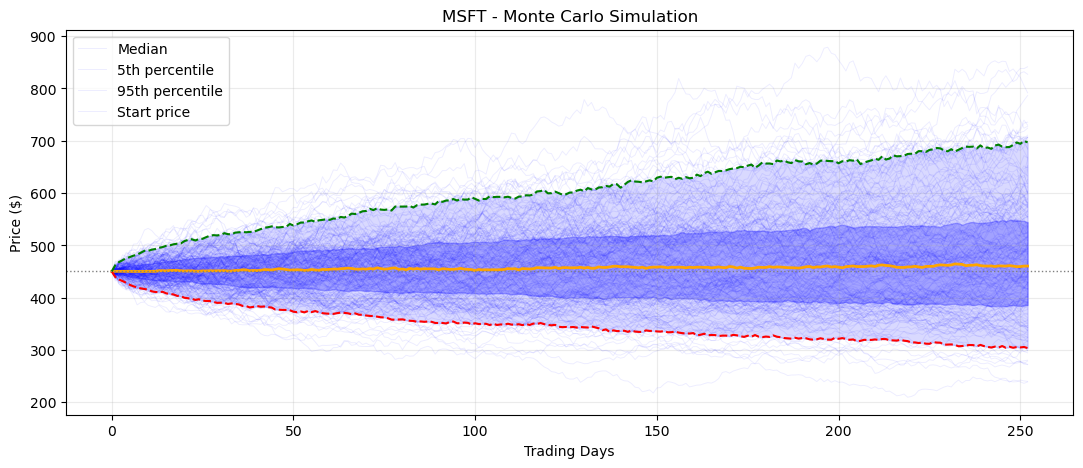

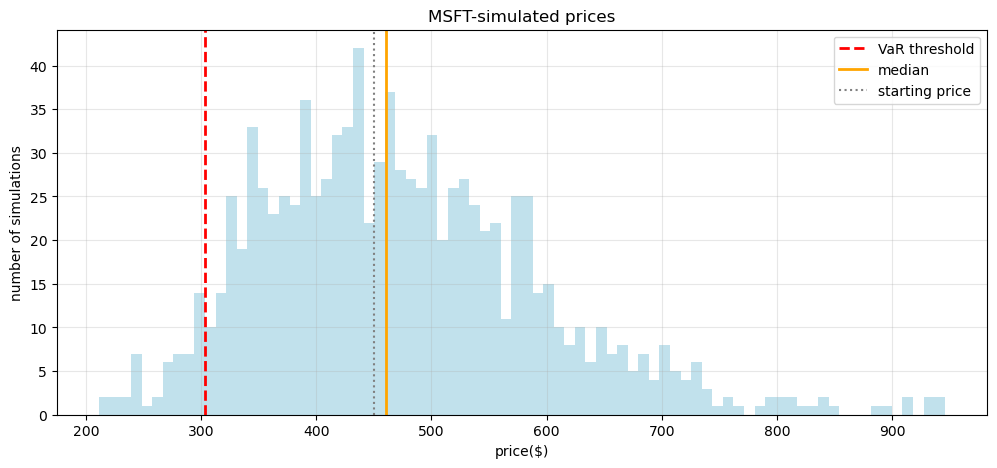


investment summary
investment: $ 10000
shares held: 22.2104
horizon: 252 days

VaR(95%): -$ 3251.36
CVaR(95%): -$ 3942.54
median P&L: $ 228.01
best case(99th): $ 8573.68

Sensitivity Table

99.0%  VaR: -$     5,118  ( 51.18%)  CVaR: -$     5,298


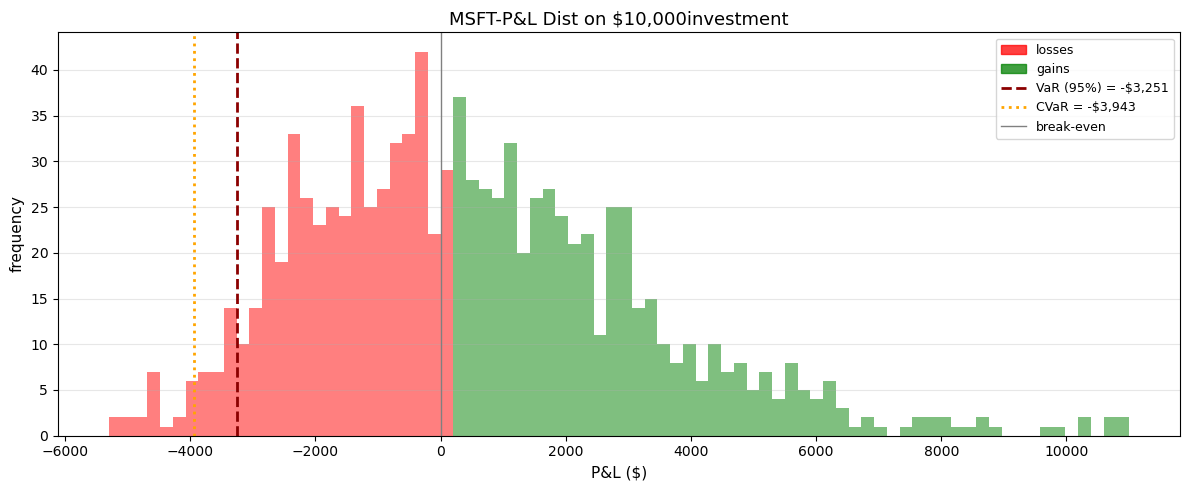

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
#change ticker accordingly
ticker='MSFT'
lookback_years=2 #years of history for mu and sigma
horizon_days=252 #trading days to simulate fowards(252=1 year)
n_simulations=1000 
confidence_level=0.95 #for VaR/CVaR
investment=10_000 #dollar amount invested
#give me 2 years of Apple price history ending today
import datetime
end_date=datetime.date.today()
start_date=end_date-datetime.timedelta(days=int(lookback_years*365.25))
print("fetching", ticker, "from", start_date, "to", end_date)
stock=yf.download(ticker, start=start_date,end=end_date,progress=False)
#if data is missing download fails or empty DataFrame
if stock.empty:
    raise ValueError(f'no data found for ticker {ticker}. check symbol')#prevents future crash
prices=stock['Close'].squeeze()#turns into a 1Xn matrix
log_returns=np.log(prices/prices.shift(1)).dropna()
#daily stats
mu_daily=log_returns.mean()
sigma_daily=log_returns.std()
#annual
mu_annual=mu_daily*252
sigma_annual=sigma_daily*np.sqrt(252)
S0=float(prices.iloc[-1])#gives latest closing prices
print("Ticker:", ticker)
print("last close: $", round(S0, 2))
print("trading days used:", len(log_returns))
print("annual return (mu):", round(mu_annual * 100, 2), "%")
print("annual volatility (sigma):", round(sigma_annual * 100, 2), "%")
print("sharpe (approx):", round(mu_annual / sigma_annual, 2))
np.random.seed(42)
dt=1/252#one trading day
z=np.random.standard_normal((horizon_days,n_simulations))
daily_returns=np.exp((mu_daily-0.5*sigma_daily**2)+sigma_daily*z)
price_paths=np.vstack([np.full(n_simulations,S0),S0*np.cumprod(daily_returns,axis=0)])
final_prices=price_paths[-1]
median_price=np.median(final_prices)
percentile_5=np.percentile(final_prices,5)
percentile_95=np.percentile(final_prices,95)
print("simulated", n_simulations, "paths over", horizon_days, "trading days.")
print("starting price: $", round(S0,2))
print("median end price: $", round(median_price,2))
print("5th percentile end price: $", round(percentile_5,2))
print("95th percentile end price: $", round(percentile_95,2))
fig,ax=plt.subplots(figsize=(13,5))
days=np.arange(horizon_days+1)
num_paths=min(200,n_simulations)
for i in range(num_paths):
    ax.plot(days, price_paths[:, i], alpha=0.07, linewidth=0.7, color='blue')
low_5 = np.percentile(price_paths, 5, axis=1)
low_25 = np.percentile(price_paths, 25, axis=1)
median = np.percentile(price_paths, 50, axis=1)
high_75 = np.percentile(price_paths, 75, axis=1)
high_95 = np.percentile(price_paths, 95, axis=1)
ax.fill_between(days, low_5, high_95, alpha=0.15, color='blue')
ax.fill_between(days, low_25, high_75, alpha=0.25, color='blue')
ax.plot(days, median, color='orange', linewidth=2)
ax.plot(days, low_5, color='red', linewidth=1.5, linestyle='--')
ax.plot(days, high_95, color='green', linewidth=1.5, linestyle='--')
ax.axhline(S0, color='gray', linewidth=1, linestyle=':')
ax.set_title(ticker + " - Monte Carlo Simulation")
ax.set_xlabel("Trading Days")
ax.set_ylabel("Price ($)")
ax.legend(["Median", "5th percentile", "95th percentile", "Start price"])
ax.grid(alpha=0.25)
plt.show()
fig,ax=plt.subplots(figsize=(12,5))
percent_for_var=(1-confidence_level)*100
var_price=np.percentile(final_prices,percent_for_var)
ax.hist(final_prices,bins=80,edgecolor='none',alpha=0.75,color='lightblue')
ax.axvline(var_price,color='red',linewidth=2,linestyle='--')
ax.axvline(np.median(final_prices),color='orange',linewidth=2)
ax.axvline(S0,color='gray',linewidth=1.5,linestyle=':')
ax.set_title(ticker+'-simulated prices')
ax.set_xlabel('price($)')
ax.set_ylabel('number of simulations')
ax.legend(['VaR threshold','median','starting price'])
ax.grid(alpha=0.3)
plt.show()
shares=investment/S0
pnl=shares*(final_prices-S0)
var_percent=(1-confidence_level)*100
var_pnl=-np.percentile(pnl, var_percent)
worse_than_var=pnl[pnl<=-var_pnl]
cvar_pnl=-worse_than_var.mean()
median_pnl=np.median(pnl)
best_case_pnl=np.percentile(pnl,99)
print('')
print('investment summary')
print('investment: $',investment)
print('shares held:', round(shares,4))
print('horizon:',horizon_days,'days')
print('')
print('VaR(95%): -$',round(var_pnl,2))
print('CVaR(95%): -$',round(cvar_pnl,2))
print('median P&L: $', round(median_pnl,2))
print('best case(99th): $',round(best_case_pnl,2))
print('')
print('Sensitivity Table')
print('')
for cl in [0.90, 0.95, 0.975, 0.99, 0.999]:
    var_calc_percent=(1-cl)*100
    var_at_cl=-np.percentile(pnl,var_calc_percent)
    worse_than_var_cl=pnl[pnl<=-var_at_cl]
    cvar_at_cl=-worse_than_var_cl.mean()
    var_pct_cl = (var_at_cl / investment) * 100
    cl_percent=int(cl*100)
print("{:.1f}%  VaR: -${:>10,.0f}  ({:>6.2f}%)  CVaR: -${:>10,.0f}".format(cl_percent, var_at_cl, var_pct_cl, cvar_at_cl))
investment_formatted=format(investment,',.0f')
var_rounded=round(var_pnl)
cvar_rounded=round(cvar_pnl)
confidence_percent=int(confidence_level*100)
title_text=ticker+'-P&L Dist on $'+investment_formatted+'investment'
var_label = "VaR (" + str(confidence_percent) + "%) = -$" + "{:,.0f}".format(var_rounded)
cvar_label = "CVaR = -$" + "{:,.0f}".format(cvar_rounded)

fig,ax=plt.subplots(figsize=(12,5))  # Changed from 'fix' to 'fig'
counts,bin_edges,patches=ax.hist(pnl,bins=80,edgecolor='none')
for patch,left in zip(patches,bin_edges[:-1]):
    if left<0:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('green')
    patch.set_alpha(0.5)
ax.axvline(-var_pnl, color='darkred',linewidth=2,linestyle='--',label=var_label)
ax.axvline(-cvar_pnl,color='orange',linewidth=2,linestyle=':',label=cvar_label)
ax.axvline(0,color='gray',linewidth=1,linestyle='-',label='break-even')
loss_patch=mpatches.Patch(color='red',alpha=0.75,label='losses')
gain_patch=mpatches.Patch(color='green',alpha=0.75,label='gains')
ax.set_title(title_text,fontsize=13)
ax.set_xlabel('P&L ($)',fontsize=11)
ax.set_ylabel('frequency',fontsize=11)
handles,labels=ax.get_legend_handles_labels()
ax.legend(handles=[loss_patch,gain_patch]+handles,fontsize=9)
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()
#If you see:                           It means:
#━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#Sharpe = 0.70                         Excellent risk-adjusted returns,This measures return per unit of risk
#Sharpe = 0.20                         Poor return for the risk taken
#VaR = -$500 (95%)                     You'll lose >$500 only 5% of the time
#CVaR = -$800 (95%)                    When you lose, average loss is $800
#Probability Loss = 40%                60% chance of profit (favorable)
#Probability Loss = 55%                More likely to lose than gain
#Risk/Reward = 1:0.5                   Downside is HALF of upside (good)
#Risk/Reward = 1:3                     Downside is 3× upside (bad)
#Final Price 5th %ile < S0             20%+ chance of losing money
#Final Price median > S0               Most likely scenario is profit

In [ ]:
# ── LLM investment report (Google Gemini) ────────────────────────────────
# Turns the Monte Carlo numbers above into a plain-English report for a layman.
# The API key is read from the environment (or a local .env file) — never hard-coded.
import os
from google import genai

# Optionally load a local .env file (pip install python-dotenv).
# Create a .env next to this notebook containing:  GEMINI_API_KEY=your_key_here
# The .env file is git-ignored, so your key is never committed.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
if not api_key:
    raise ValueError(
        "No Gemini API key found. Set GEMINI_API_KEY (or GOOGLE_API_KEY) in your "
        "environment, or put it in a local .env file next to this notebook. "
        "Get a free key at https://aistudio.google.com/apikey"
    )

# Extra stats derived from the simulation for the report
prob_loss = float((pnl < 0).mean()) * 100          # % of simulations that lost money
prob_profit = 100 - prob_loss
expected_pnl = float(pnl.mean())                    # average dollar outcome
ret_if_median = (median_price / S0 - 1) * 100       # % move in the median scenario

# Compact, factual summary handed to the model (no advice baked in)
stats_summary = f"""
Stock ticker: {ticker}
Investment amount: ${investment:,.0f}
Shares this buys: {shares:.4f}
Time horizon: {horizon_days} trading days (~1 year)
Number of simulated scenarios: {n_simulations}

Current price: ${S0:,.2f}
Historical annual return (drift): {mu_annual*100:.2f}%
Historical annual volatility (risk): {sigma_annual*100:.2f}%
Approx. Sharpe ratio: {mu_annual/sigma_annual:.2f}

Simulated 1-year outcomes:
- Median end price: ${median_price:,.2f}  (a {ret_if_median:+.1f}% move)
- Pessimistic (5th percentile) end price: ${percentile_5:,.2f}
- Optimistic (95th percentile) end price: ${percentile_95:,.2f}

Profit/Loss on the ${investment:,.0f} investment:
- Chance of LOSING money: {prob_loss:.1f}%
- Chance of MAKING money: {prob_profit:.1f}%
- Average (expected) result: ${expected_pnl:,.2f}
- Median result: ${median_pnl:,.2f}
- VaR ({int(confidence_level*100)}%): you would lose more than ${var_pnl:,.2f} only {(1-confidence_level)*100:.0f}% of the time
- CVaR ({int(confidence_level*100)}%): in those worst cases, the average loss is ${cvar_pnl:,.2f}
- Best case (99th percentile): ${best_case_pnl:,.2f}
""".strip()

prompt = f"""You are a friendly financial educator writing for a complete beginner (a layman)
who has never invested before. Below are the results of a Monte Carlo simulation for a
potential stock investment.

Write a clear, jargon-free report (about 250-350 words) that:
1. Explains in one short paragraph what this simulation actually estimated.
2. Summarizes the likely outcomes in plain words (use the numbers, but explain what they mean,
   e.g. what "you could lose more than $X 5% of the time" means in real life).
3. Lists the key RISKS and the key UPSIDES as short bullet points.
4. Gives a balanced "what this suggests" section. Frame it as considerations, not a command.
Define any term the first time you use it (volatility, VaR, etc.) in a few words.
End with a one-line plain-English disclaimer that this is educational, not financial advice,
and that past performance does not guarantee future results.

Here is the simulation data:
{stats_summary}
"""

client = genai.Client(api_key=api_key)
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
)

print("=" * 70)
print(f"  INVESTMENT REPORT — {ticker}  (${investment:,.0f} over ~1 year)")
print("=" * 70)
print(response.text)

In [8]:
# ── Build a distributable PDF report (graphs + analysis) ─────────────────
# Bundles the Monte Carlo charts and the written analysis into one PDF.
# Run the simulation cell and the Gemini report cell first.
import os, re, textwrap, datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# --- gather the analysis text (use the LLM report if available) ----------
try:
    analysis_text = response.text
except NameError:
    analysis_text = ("LLM report not generated (run the Gemini cell first). "
                     "This PDF contains the charts and summary statistics only.")

# recompute a couple of stats in case the report cell wasn't run
prob_loss = float((pnl < 0).mean()) * 100
prob_profit = 100 - prob_loss
expected_pnl = float(pnl.mean())

# strip basic markdown so it renders cleanly as plain text in the PDF
def strip_markdown(t):
    t = re.sub(r"\*\*(.+?)\*\*", r"\1", t)      # **bold** -> bold
    t = re.sub(r"(?m)^\s*#{1,6}\s*", "", t)      # headings
    t = re.sub(r"(?m)^\s*[\*\-]\s+", "  • ", t)  # bullets -> •
    return t.strip()

analysis_clean = strip_markdown(analysis_text)

report_date = datetime.date.today().strftime("%B %d, %Y")
out_path = os.path.join(os.getcwd(), f"{ticker}_investment_report.pdf")

with PdfPages(out_path) as pdf:
    # ---- Page 1: cover + key metrics ------------------------------------
    fig = plt.figure(figsize=(8.5, 11))
    fig.text(0.5, 0.92, f"{ticker} — Investment Outlook", ha="center", fontsize=24, fontweight="bold")
    fig.text(0.5, 0.88, f"Monte Carlo simulation • {report_date}", ha="center", fontsize=12, color="gray")
    fig.text(0.5, 0.85, f"${investment:,.0f} invested over ~1 year ({horizon_days} trading days)",
             ha="center", fontsize=12)

    metrics = [
        ("Current price", f"${S0:,.2f}"),
        ("Shares purchased", f"{shares:.4f}"),
        ("Historical annual return", f"{mu_annual*100:.1f}%"),
        ("Historical volatility (risk)", f"{sigma_annual*100:.1f}%"),
        ("Chance of making money", f"{prob_profit:.1f}%"),
        ("Chance of losing money", f"{prob_loss:.1f}%"),
        ("Median end price", f"${median_price:,.2f}"),
        ("Pessimistic (5th pct) price", f"${percentile_5:,.2f}"),
        ("Optimistic (95th pct) price", f"${percentile_95:,.2f}"),
        ("Expected profit/loss", f"${expected_pnl:,.2f}"),
        ("Median profit/loss", f"${median_pnl:,.2f}"),
        (f"VaR ({int(confidence_level*100)}%)", f"-${var_pnl:,.2f}"),
        (f"CVaR ({int(confidence_level*100)}%)", f"-${cvar_pnl:,.2f}"),
        ("Best case (99th pct)", f"${best_case_pnl:,.2f}"),
    ]
    ax = fig.add_axes([0.12, 0.18, 0.76, 0.60]); ax.axis("off")
    tbl = ax.table(cellText=metrics, colLabels=["Metric", "Value"],
                   cellLoc="left", colLoc="left", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#34495e"); cell.set_text_props(color="white", fontweight="bold")
        elif r % 2:
            cell.set_facecolor("#f2f4f6")
    fig.text(0.5, 0.06,
             "Educational use only — not financial advice. Past performance does not guarantee future results.",
             ha="center", fontsize=8, style="italic", color="gray")
    pdf.savefig(fig); plt.close(fig)

    # ---- Page 2: simulated price paths (fan chart) ----------------------
    fig, ax = plt.subplots(figsize=(11, 8.5))
    for i in range(min(200, n_simulations)):
        ax.plot(days, price_paths[:, i], alpha=0.07, linewidth=0.7, color="blue")
    ax.fill_between(days, low_5, high_95, alpha=0.15, color="blue")
    ax.fill_between(days, low_25, high_75, alpha=0.25, color="blue")
    ax.plot(days, median, color="orange", linewidth=2, label="Median")
    ax.plot(days, low_5, color="red", linewidth=1.5, linestyle="--", label="5th percentile")
    ax.plot(days, high_95, color="green", linewidth=1.5, linestyle="--", label="95th percentile")
    ax.axhline(S0, color="gray", linewidth=1, linestyle=":", label="Start price")
    ax.set_title(f"{ticker} — Simulated Price Paths (1 year)", fontsize=15, fontweight="bold")
    ax.set_xlabel("Trading Days"); ax.set_ylabel("Price ($)")
    ax.legend(); ax.grid(alpha=0.25)
    pdf.savefig(fig); plt.close(fig)

    # ---- Page 3: distribution of final prices ---------------------------
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.hist(final_prices, bins=80, edgecolor="none", alpha=0.75, color="lightblue")
    ax.axvline(var_price, color="red", linewidth=2, linestyle="--", label="VaR threshold")
    ax.axvline(median_price, color="orange", linewidth=2, label="Median")
    ax.axvline(S0, color="gray", linewidth=1.5, linestyle=":", label="Start price")
    ax.set_title(f"{ticker} — Distribution of Simulated End Prices", fontsize=15, fontweight="bold")
    ax.set_xlabel("Price ($)"); ax.set_ylabel("Number of simulations")
    ax.legend(); ax.grid(alpha=0.3)
    pdf.savefig(fig); plt.close(fig)

    # ---- Page 4: P&L distribution ---------------------------------------
    fig, ax = plt.subplots(figsize=(11, 8.5))
    counts, bin_edges, patches = ax.hist(pnl, bins=80, edgecolor="none")
    for patch, left in zip(patches, bin_edges[:-1]):
        patch.set_facecolor("red" if left < 0 else "green"); patch.set_alpha(0.5)
    ax.axvline(-var_pnl, color="darkred", linewidth=2, linestyle="--",
               label=f"VaR ({int(confidence_level*100)}%) = -${var_pnl:,.0f}")
    ax.axvline(-cvar_pnl, color="orange", linewidth=2, linestyle=":", label=f"CVaR = -${cvar_pnl:,.0f}")
    ax.axvline(0, color="gray", linewidth=1, label="break-even")
    ax.set_title(f"{ticker} — Profit/Loss Distribution on ${investment:,.0f}", fontsize=15, fontweight="bold")
    ax.set_xlabel("Profit / Loss ($)"); ax.set_ylabel("Frequency")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    pdf.savefig(fig); plt.close(fig)

    # ---- Page 5+: written analysis (paginated) --------------------------
    wrapped = []
    for para in analysis_clean.split("\n"):
        wrapped += textwrap.wrap(para, width=95) or [""]
    lines_per_page = 50
    for pg in range(0, len(wrapped), lines_per_page):
        chunk = wrapped[pg:pg + lines_per_page]
        fig = plt.figure(figsize=(8.5, 11)); fig.axes
        if pg == 0:
            fig.text(0.5, 0.95, "Analysis", ha="center", fontsize=18, fontweight="bold")
            y0 = 0.90
        else:
            y0 = 0.94
        fig.text(0.08, y0, "\n".join(chunk), ha="left", va="top", fontsize=10.5, family="monospace")
        pdf.savefig(fig); plt.close(fig)

    # PDF metadata
    d = pdf.infodict()
    d["Title"] = f"{ticker} Investment Outlook"
    d["Subject"] = "Monte Carlo simulation report"

print(f"PDF saved to: {out_path}")

PDF saved to: /Users/upasy/myschool_repo/practice/MSFT_investment_report.pdf
